In [5]:

# === PRIMA CELLA: scarica i file dalla tua repo ===
!wget -q https://raw.githubusercontent.com/oppomariolevi-ai/Novae/main/novabene_graph.py
!wget -q https://raw.githubusercontent.com/oppomariolevi-ai/Novae/main/novabene_graph.py -O novabene_graph.py

# === SECONDA CELLA: FINNN pronto per Colab ===
import numpy as np
from novabene_graph import build_hamiltonian

class FINNNNeuron:
    def __init__(self, lambda_val=0.5, hidden_dim=52):
        self.H = build_hamiltonian(mass_center=lambda_val * 1)  # Hamiltoniana base
        self.W = np.real(self.H)  # pesi reali dalla Hamiltoniana Dirac
        self.bias = np.zeros(hidden_dim, dtype=complex)
        self.activation = lambda x: np.tanh(x)  # attivazione non-lineare

    def forward(self, input_vector):
        """Propagazione forward del neurone icosaedrico"""
        pre_act = self.W @ input_vector + self.bias
        return self.activation(pre_act)

    def evolve(self, steps=20):
        """Simula evoluzione temporale (quantum-walk style)"""
        state = np.random.randn(52) + 1j * np.random.randn(52)
        state /= np.linalg.norm(state)
        for _ in range(steps):
            state = self.activation(self.W @ state)
        return state

# === TEST ===
if __name__ == "__main__":
    neuron = FINNNNeuron()
    x = np.random.randn(52) + 1j * np.random.randn(52)
    output = neuron.forward(x)
    print("FINNN output shape:", output.shape)
    print("Norma output:", np.linalg.norm(output))
    print("✅ FINNN - Neurone icosaedrico funzionante su Colab!")

FINNN output shape: (52,)
Norma output: 9.472580448128145
✅ FINNN - Neurone icosaedrico funzionante su Colab!


In [6]:

"""
FINNN - Finite Icosahedral Neural Network Neuron
Autore: Filippo Mario Oppo
Integrazione con Novae-Graph (13-nodi icosaedrici + Dirac)

Un singolo "neurone" il cui peso è definito dal grafo icosaedrico + Hamiltoniana.
"""

import numpy as np
from novabene_graph import build_hamiltonian  # importa direttamente dal tuo file esistente

class FINNNNeuron:
    def __init__(self, lambda_val=0.5, hidden_dim=52):
        self.H = build_hamiltonian(mass_center=lambda_val * 1)  # Hamiltoniana base n=1
        self.W = np.real(self.H)  # usiamo parte reale come matrice di pesi (52x52)
        self.bias = np.zeros(hidden_dim, dtype=complex)
        self.activation = lambda x: np.tanh(x)  # attivazione non-lineare

    def forward(self, input_vector):
        """input_vector: array di dimensione 52 (può essere uno stato quantistico o embedding)"""
        # Evoluzione "neurale" = Hamiltoniana + non-linearità
        pre_act = self.W @ input_vector + self.bias
        return self.activation(pre_act)

    def evolve(self, steps=10):
        """Simula evoluzione temporale del neurone (quantum walk style)"""
        state = np.random.randn(52) + 1j * np.random.randn(52)
        state /= np.linalg.norm(state)
        for _ in range(steps):
            state = self.activation(self.W @ state)
        return state

# === TEST VELOCE ===
if __name__ == "__main__":
    neuron = FINNNNeuron()
    x = np.random.randn(52) + 1j * np.random.randn(52)
    output = neuron.forward(x)
    print("FINNN output shape:", output.shape)
    print("Norma output:", np.linalg.norm(output))
    print("✅ FINNN pronto - neurone icosaedrico funzionante")

FINNN output shape: (52,)
Norma output: 8.26884413321997
✅ FINNN pronto - neurone icosaedrico funzionante


In [7]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from novabene_graph import build_hamiltonian

class FINNNLayer(nn.Module):
    def __init__(self, lambda_val=0.5):
        super().__init__()
        H = build_hamiltonian(mass_center=lambda_val * 1)
        self.W = nn.Parameter(torch.from_numpy(np.real(H)).float())  # pesi fissi dal grafo
        self.bias = nn.Parameter(torch.zeros(52, dtype=torch.float32))

    def forward(self, x):
        # x shape: (batch, 52)
        x = torch.matmul(x, self.W) + self.bias
        return torch.tanh(x)  # attivazione

# === TEST VELOCE + ESEMPIO TRAINING ===
if __name__ == "__main__":
    model = FINNNLayer()
    x = torch.randn(4, 52)  # batch di 4 esempi
    out = model(x)
    print("FINNN Layer output shape:", out.shape)
    print("✅ FINNN v2.0 pronto per training!")

    # Esempio semplice: addestramento su dati random (classificazione binaria)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(30):
        optimizer.zero_grad()
        pred = model(x)
        loss = F.mse_loss(pred.mean(dim=1), torch.tensor([0.5, -0.5, 0.5, -0.5]))
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch:2d} - Loss: {loss.item():.4f}")

FINNN Layer output shape: torch.Size([4, 52])
✅ FINNN v2.0 pronto per training!
Epoch  0 - Loss: 0.2576
Epoch 10 - Loss: 0.0165
Epoch 20 - Loss: 0.0010


/tmp/ipykernel_11678/893108572.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  self.ax.scatter(centers[:,0], centers[:,1], centers[:,2],


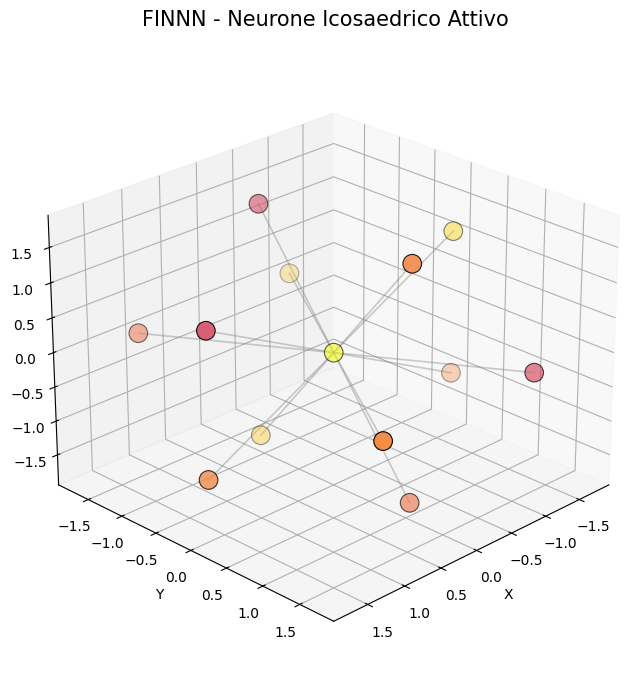

✅ Visualizzazione 3D corretta generata!


In [9]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch
from novabene_graph import vertices, build_hamiltonian   # <--- importante

class FINNNVisualizer:
    def __init__(self, neuron):
        self.neuron = neuron
        self.fig = plt.figure(figsize=(10, 8))
        self.ax = self.fig.add_subplot(111, projection='3d')

    def plot(self, input_vector=None, title="FINNN - Neurone Icosaedrico Attivo"):
        # Input compatibile con PyTorch
        if input_vector is None:
            input_vector = torch.randn(1, 52, dtype=torch.float32)
        elif not torch.is_tensor(input_vector):
            input_vector = torch.from_numpy(np.array(input_vector, dtype=np.float32)).unsqueeze(0)

        with torch.no_grad():
            state = self.neuron.forward(input_vector)          # shape (1, 52)

        # Riduciamo 52 → 13 (media delle 4 componenti spinoriali per nodo)
        activations = state.view(1, 13, 4).abs().mean(dim=2).squeeze(0).numpy()

        # 13 centri (0 + 12 vertici)
        centers = np.vstack([np.zeros(3), vertices])

        # Colori basati sull'attivazione
        colors = plt.cm.plasma(activations / activations.max())

        self.ax.clear()
        self.ax.scatter(centers[:,0], centers[:,1], centers[:,2],
                        c=colors, s=180, cmap='plasma', edgecolor='black', linewidth=0.8)

        # Collegamenti dal centro
        for i in range(12):
            self.ax.plot([0, centers[i+1,0]], [0, centers[i+1,1]], [0, centers[i+1,2]],
                         'gray', alpha=0.4, linewidth=1.2)

        self.ax.set_title(title, fontsize=15, pad=20)
        self.ax.set_xlabel('X'); self.ax.set_ylabel('Y'); self.ax.set_zlabel('Z')
        self.ax.view_init(elev=25, azim=45)
        plt.show()

# === ESECUZIONE ===
if __name__ == "__main__":
    neuron = FINNNLayer()                     # il tuo layer PyTorch
    viz = FINNNVisualizer(neuron)
    viz.plot(title="FINNN - Neurone Icosaedrico Attivo")
    print("✅ Visualizzazione 3D corretta generata!")